# Autism Dataset Data Exploration

This notebook explores the autism detection dataset for Kaggle, focusing on both raw data (before cleaning and splitting) and processed data (after preprocessing), to understand the data pipeline and quality.

## 1. Import Required Libraries

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support

# --- CONFIGURATION ---
HEIGHT, WIDTH = 224, 224
BATCH_SIZE = 32
OUTPUT_DIR = 'results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load the trained model
model_path = 'final_model.h5'
print(f"Loading model from {model_path}")
model = load_model(model_path, compile=False)
print("✓ Model loaded")

# Data generators
test_datagen = ImageDataGenerator(rescale=1./255)

TestGen = test_datagen.flow_from_directory(
    'Kaggle-Autism/data/test',
    target_size=(HEIGHT, WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)
print(f"✓ Test data loaded: {TestGen.samples} samples")

# --- EVALUATION ---
print("\n" + "="*60)
print("📊 EVALUATION")
print("="*60)

# Evaluate on test set
test_loss, test_acc = model.evaluate(TestGen, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Get predictions (binary)
Y_pred_proba = model.predict(TestGen, verbose=0).flatten()
Y_pred = (Y_pred_proba > 0.5).astype(int)
Y_true = TestGen.classes

# Confusion matrix
cm = confusion_matrix(Y_true, Y_pred)
print("\nConfusion Matrix:")
print(cm)

# Classification report
print("\nClassification Report:")
print(classification_report(Y_true, Y_pred, target_names=['Autistic', 'Non_Autistic']))

# Detailed metrics
precision, recall, f1, _ = precision_recall_fscore_support(Y_true, Y_pred, average='weighted')
print(f"\nWeighted Metrics:")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"  F1-Score: {f1:.4f}")

# --- PLOTTING ---
print("\n" + "="*60)
print("📈 GENERATING PLOTS")
print("="*60)

# Confusion matrix plot
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='Blues', aspect='auto')
ax.set_xlabel('Predicted', fontsize=12, weight='bold')
ax.set_ylabel('True', fontsize=12, weight='bold')
ax.set_title('Confusion Matrix', fontsize=14, weight='bold')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Autistic', 'Non_Autistic'], fontsize=11)
ax.set_yticklabels(['Autistic', 'Non_Autistic'], fontsize=11)
plt.colorbar(im, ax=ax)

for i in range(2):
    for j in range(2):
        text_color = 'white' if cm[i, j] > cm.max()/2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
               color=text_color, fontsize=20, weight='bold')

plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=100, bbox_inches='tight')
print("✓ Confusion matrix saved")
plt.show()

# Save metrics summary
with open(os.path.join(OUTPUT_DIR, 'metrics_summary.txt'), 'w') as f:
    f.write("="*60 + "\n")
    f.write("AUTISM DETECTION MODEL - EVALUATION SUMMARY\n")
    f.write("="*60 + "\n\n")
    f.write(f"Test Accuracy: {test_acc:.4f}\n")
    f.write(f"Test Loss: {test_loss:.4f}\n")
    f.write(f"Precision: {precision:.4f}\n")
    f.write(f"Recall: {recall:.4f}\n")
    f.write(f"F1-Score: {f1:.4f}\n\n")
    f.write(f"Confusion Matrix:\n{cm}\n\n")
    f.write(f"Classification Report:\n")
    f.write(classification_report(Y_true, Y_pred, target_names=['Autistic', 'Non_Autistic']))

print("✓ Metrics summary saved")

print(f"\n✅ All results saved to: {OUTPUT_DIR}")
print("="*60 + "\n")

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import glob
from collections import Counter
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set style for plots
plt.style.use('default')

print("Libraries imported successfully!")

I0000 00:00:1776357477.277996  137103 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776357477.368564  137103 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776357478.919494  137103 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Libraries imported successfully!


## 2. Load Dataset

In [2]:
# Define dataset paths (adjust for Kaggle)
DATASET_PATH = '../Kaggle-Autism/data/consolidated'  # Adjust this path based on your Kaggle dataset structure
RAW_AUTISTIC_PATH = os.path.join(DATASET_PATH, 'raw', 'Autistic')
RAW_NON_AUTISTIC_PATH = os.path.join(DATASET_PATH, 'raw', 'Non_Autistic')

# Check if paths exist
print("Raw dataset paths:")
print(f"Autistic: {RAW_AUTISTIC_PATH} - Exists: {os.path.exists(RAW_AUTISTIC_PATH)}")
print(f"Non_Autistic: {RAW_NON_AUTISTIC_PATH} - Exists: {os.path.exists(RAW_NON_AUTISTIC_PATH)}")

# Alternative: Use local paths if running locally
if not os.path.exists(RAW_AUTISTIC_PATH):
    RAW_AUTISTIC_PATH = '../Kaggle-Autism/data/consolidated/Autistic'
    RAW_NON_AUTISTIC_PATH = '../Kaggle-Autism/data/consolidated/Non_Autistic'
    print("\nUsing local paths:")
    print(f"Autistic: {RAW_AUTISTIC_PATH}")
    print(f"Non_Autistic: {RAW_NON_AUTISTIC_PATH}")

# For processed data (after cleaning/splitting)
TRAIN_PATH = '../Kaggle-Autism/data/train'
VALID_PATH = '../Kaggle-Autism/data/valid'
TEST_PATH = '../Kaggle-Autism/data/test'

Raw dataset paths:
Autistic: ../Kaggle-Autism/data/consolidated/raw/Autistic - Exists: False
Non_Autistic: ../Kaggle-Autism/data/consolidated/raw/Non_Autistic - Exists: False

Using local paths:
Autistic: ../Kaggle-Autism/data/consolidated/Autistic
Non_Autistic: ../Kaggle-Autism/data/consolidated/Non_Autistic


## 3. Explore Raw Data Structure (Before Cleaning & Splitting)

In [1]:
def explore_raw_data(autistic_path, non_autistic_path):
    """Explore the raw data before cleaning and splitting"""
    print("=== RAW DATA EXPLORATION ===")
    
    raw_counts = {}
    total_raw = 0
    
    for class_name, path in [("Autistic", autistic_path), ("Non_Autistic", non_autistic_path)]:
        if os.path.exists(path):
            images = glob.glob(os.path.join(path, '*.jpg')) + glob.glob(os.path.join(path, '*.png'))
            raw_counts[class_name] = len(images)
            total_raw += len(images)
            print(f"{class_name}: {len(images)} images")
        else:
            print(f"{class_name} path does not exist: {path}")
            raw_counts[class_name] = 0
    
    print(f"Total raw images: {total_raw}")
    return raw_counts

# Explore raw data
raw_counts = explore_raw_data(RAW_AUTISTIC_PATH, RAW_NON_AUTISTIC_PATH)


# Summary
print("\n=== DATASET SUMMARY ===")
print(f"Raw data: {sum(raw_counts.values())} images")
print(f"Classes: {list(raw_counts.keys())}")


NameError: name 'RAW_AUTISTIC_PATH' is not defined

## 4. Visualize Class Distributions

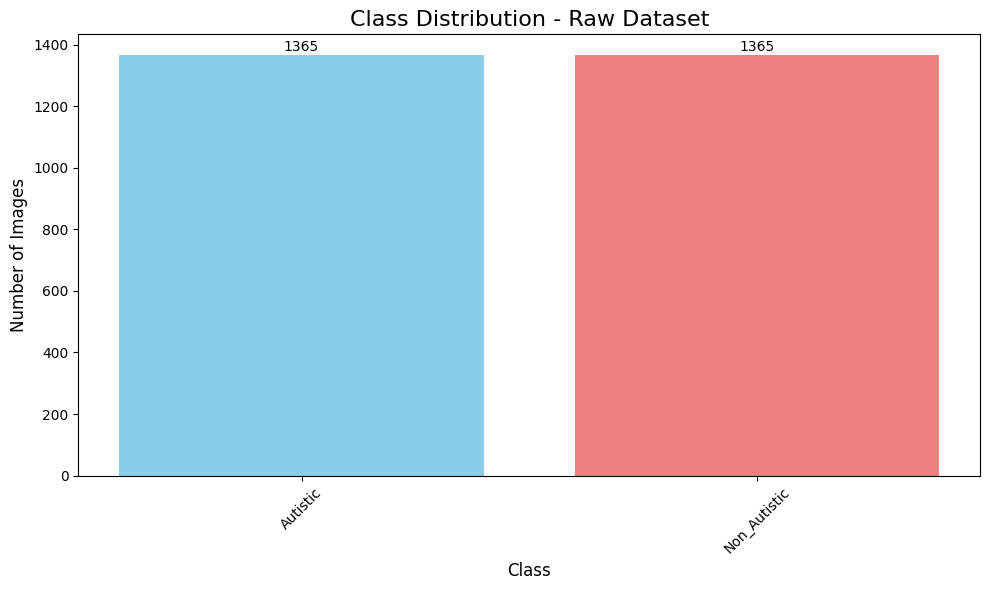

NameError: name 'train_counts' is not defined

In [5]:
def plot_class_distribution(counts_dict, title):
    """Plot class distribution as bar chart"""
    if not counts_dict:
        print(f"No data for {title}")
        return
    
    classes = list(counts_dict.keys())
    counts = list(counts_dict.values())
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(classes, counts, color=['skyblue', 'lightcoral'])
    plt.title(f'Class Distribution - {title}', fontsize=16)
    plt.xlabel('Class', fontsize=12)
    plt.ylabel('Number of Images', fontsize=12)
    plt.xticks(rotation=45)
    
    # Add value labels on bars
    for bar, count in zip(bars, counts):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                str(count), ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

# Plot raw data distribution
if raw_counts:
    plot_class_distribution(raw_counts, "Raw Dataset")

# Plot distributions for each split
if train_counts:
    plot_class_distribution(train_counts, "Training Set")
if valid_counts:
    plot_class_distribution(valid_counts, "Validation Set")
if test_counts:
    plot_class_distribution(test_counts, "Test Set")

# Combined plot including raw
if raw_counts and train_counts and valid_counts and test_counts:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    for i, (counts, title) in enumerate([(raw_counts, "Raw"), (train_counts, "Train"), (valid_counts, "Valid"), (test_counts, "Test")]):
        row, col = i // 2, i % 2
        classes = list(counts.keys())
        values = list(counts.values())
        axes[row, col].bar(classes, values, color=['skyblue', 'lightcoral'])
        axes[row, col].set_title(f'{title} Set')
        axes[row, col].set_xlabel('Class')
        axes[row, col].set_ylabel('Count')
        axes[row, col].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

## 5. Visualize Sample Images


Sample images from raw Autistic class:


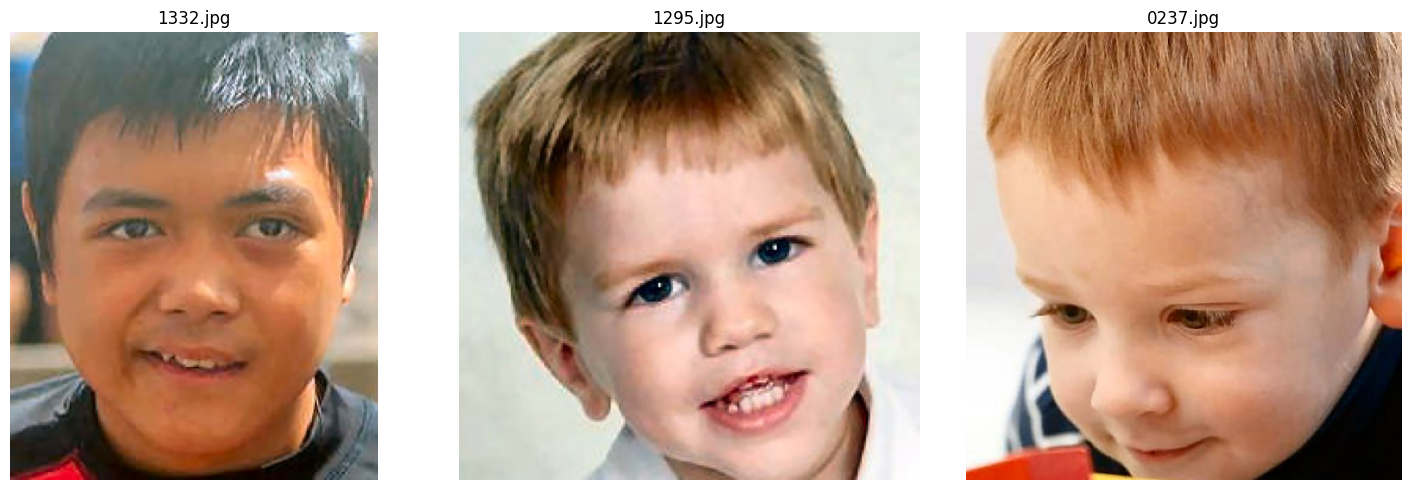


Sample images from raw Non_Autistic class:


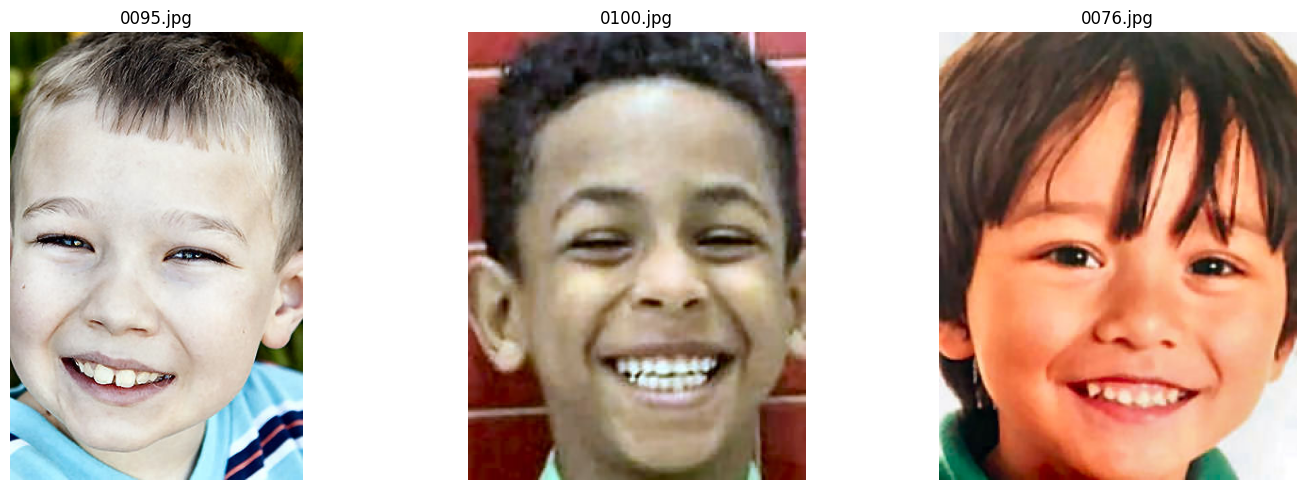

NameError: name 'train_counts' is not defined

In [6]:
def show_sample_images(base_path, class_name="", num_samples=5):
    """Show sample images from a class or flat directory"""
    if class_name:
        class_path = os.path.join(base_path, class_name)
    else:
        class_path = base_path
    
    images = glob.glob(os.path.join(class_path, '*.jpg')) + glob.glob(os.path.join(class_path, '*.png'))
    
    if not images:
        print(f"No images found in {class_path}")
        return
    
    # Select random samples
    samples = np.random.choice(images, min(num_samples, len(images)), replace=False)
    
    fig, axes = plt.subplots(1, len(samples), figsize=(15, 5))
    if len(samples) == 1:
        axes = [axes]
    
    for i, img_path in enumerate(samples):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            title = f"{class_name}\n{os.path.basename(img_path)}" if class_name else os.path.basename(img_path)
            axes[i].set_title(title)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
    
    plt.tight_layout()
    plt.show()

# Show samples from raw data
if raw_counts:
    for class_name in raw_counts.keys():
        if raw_counts[class_name] > 0:
            path = RAW_AUTISTIC_PATH if class_name == "Autistic" else RAW_NON_AUTISTIC_PATH
            print(f"\nSample images from raw {class_name} class:")
            show_sample_images(path, "", num_samples=3)  # Note: raw data might not have subfolders

# Show samples from training set (processed)
if train_counts and classes:
    for class_name in classes:
        print(f"\nSample images from processed {class_name} class:")
        show_sample_images(TRAIN_PATH, class_name, num_samples=3)

## 6. Image Statistics and Quality Analysis

In [7]:
def analyze_image_properties(base_path, class_name="", max_samples=100):
    """Analyze image properties like size, format, etc."""
    if class_name:
        class_path = os.path.join(base_path, class_name)
    else:
        class_path = base_path
    
    images = glob.glob(os.path.join(class_path, '*.jpg')) + glob.glob(os.path.join(class_path, '*.png'))
    
    if not images:
        return None
    
    # Sample images
    samples = np.random.choice(images, min(max_samples, len(images)), replace=False)
    
    widths, heights, formats = [], [], []
    
    for img_path in samples:
        try:
            with Image.open(img_path) as img:
                widths.append(img.size[0])
                heights.append(img.size[1])
                formats.append(img.format)
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
    
    return {
        'widths': widths,
        'heights': heights,
        'formats': formats,
        'num_samples': len(samples)
    }

# Analyze raw data
if raw_counts:
    for class_name in raw_counts.keys():
        if raw_counts[class_name] > 0:
            path = RAW_AUTISTIC_PATH if class_name == "Autistic" else RAW_NON_AUTISTIC_PATH
            print(f"\nAnalyzing raw {class_name} class:")
            stats = analyze_image_properties(path, "", max_samples=50)  # Flat directory
            if stats:
                print(f"  Samples analyzed: {stats['num_samples']}")
                print(f"  Width range: {min(stats['widths'])} - {max(stats['widths'])}")
                print(f"  Height range: {min(stats['heights'])} - {max(stats['heights'])}")
                print(f"  Average size: {np.mean(stats['widths']):.0f} x {np.mean(stats['heights']):.0f}")
                format_counts = Counter(stats['formats'])
                print(f"  Formats: {dict(format_counts)}")

# Analyze training set (processed)
if train_counts and classes:
    for class_name in classes:
        print(f"\nAnalyzing processed {class_name} class:")
        stats = analyze_image_properties(TRAIN_PATH, class_name)
        if stats:
            print(f"  Samples analyzed: {stats['num_samples']}")
            print(f"  Width range: {min(stats['widths'])} - {max(stats['widths'])}")
            print(f"  Height range: {min(stats['heights'])} - {max(stats['heights'])}")
            print(f"  Average size: {np.mean(stats['widths']):.0f} x {np.mean(stats['heights']):.0f}")
            format_counts = Counter(stats['formats'])
            print(f"  Formats: {dict(format_counts)}")

# Plot image size distributions
if raw_counts and train_counts and classes:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Raw data
    for i, class_name in enumerate(raw_counts.keys()):
        if raw_counts[class_name] > 0:
            path = RAW_AUTISTIC_PATH if class_name == "Autistic" else RAW_NON_AUTISTIC_PATH
            stats = analyze_image_properties(path, "", max_samples=50)
            if stats:
                axes[0, i].scatter(stats['widths'], stats['heights'], alpha=0.6)
                axes[0, i].set_title(f'Raw Image Sizes - {class_name}')
                axes[0, i].set_xlabel('Width')
                axes[0, i].set_ylabel('Height')
                axes[0, i].grid(True, alpha=0.3)
    
    # Processed data
    for i, class_name in enumerate(classes):
        stats = analyze_image_properties(TRAIN_PATH, class_name)
        if stats:
            axes[1, i].scatter(stats['widths'], stats['heights'], alpha=0.6)
            axes[1, i].set_title(f'Processed Image Sizes - {class_name}')
            axes[1, i].set_xlabel('Width')
            axes[1, i].set_ylabel('Height')
            axes[1, i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


Analyzing raw Autistic class:
  Samples analyzed: 50
  Width range: 131 - 642
  Height range: 137 - 691
  Average size: 286 x 330
  Formats: {'JPEG': 50}

Analyzing raw Non_Autistic class:
  Samples analyzed: 50
  Width range: 128 - 1188
  Height range: 138 - 1216
  Average size: 404 x 434
  Formats: {'JPEG': 50}


NameError: name 'train_counts' is not defined

## 7. Data Generators and Augmentation Preview

Setting up data generators...
Target size: 224x224
Batch size: 32
Found 2654 images belonging to 2 classes.
✓ Training generator: 2654 samples
Found 80 images belonging to 2 classes.
✓ Validation generator: 80 samples
Found 280 images belonging to 2 classes.
✓ Test generator: 280 samples

Class indices: {'Autistic': 0, 'Non_Autistic': 1}
Class weights: {0: np.float64(1.0), 1: np.float64(1.0)}

Preview of data augmentation:
Found 2654 images belonging to 2 classes.


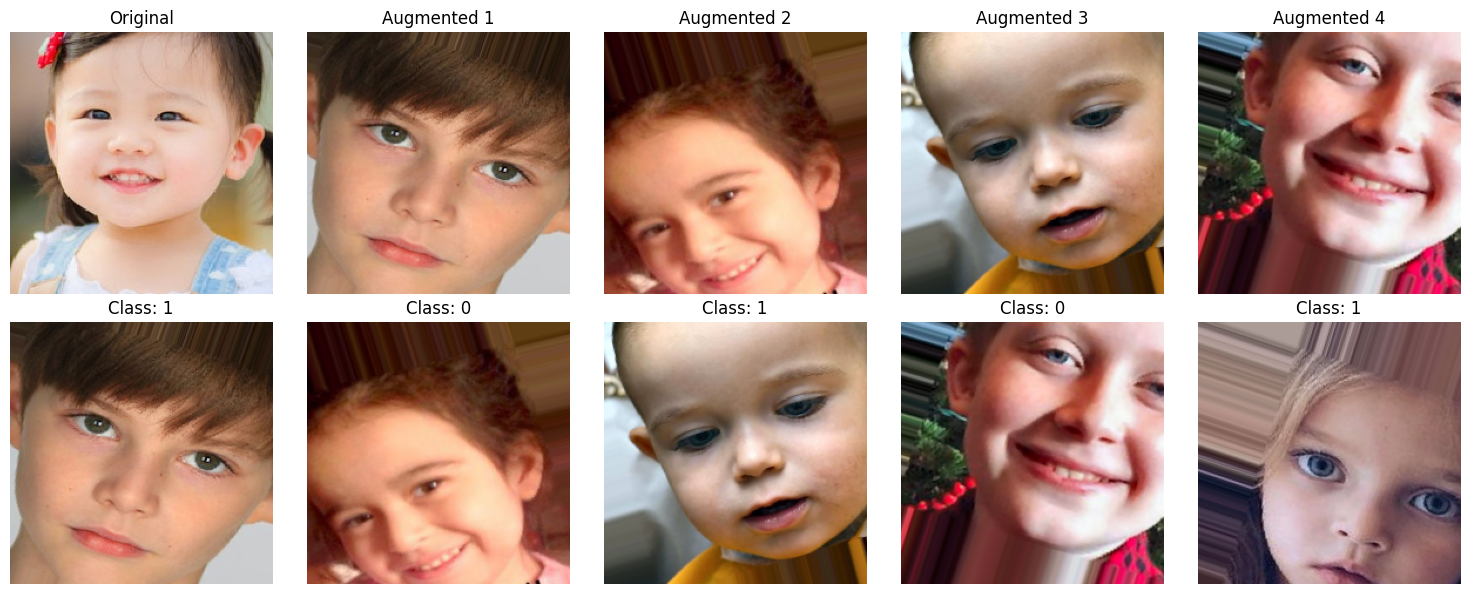

In [8]:
# Set up data generators for exploration
HEIGHT, WIDTH = 224, 224
BATCH_SIZE = 32

print("Setting up data generators...")
print(f"Target size: {HEIGHT}x{WIDTH}")
print(f"Batch size: {BATCH_SIZE}")

# Training generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2
)

# Validation/Test generator (no augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

try:
    TrainGen = train_datagen.flow_from_directory(
        TRAIN_PATH,
        target_size=(HEIGHT, WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=True
    )
    print(f"✓ Training generator: {TrainGen.samples} samples")
    
    ValidGen = test_datagen.flow_from_directory(
        VALID_PATH,
        target_size=(HEIGHT, WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=False
    )
    print(f"✓ Validation generator: {ValidGen.samples} samples")
    
    TestGen = test_datagen.flow_from_directory(
        TEST_PATH,
        target_size=(HEIGHT, WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=False
    )
    print(f"✓ Test generator: {TestGen.samples} samples")
    
    # Class indices
    print(f"\nClass indices: {TrainGen.class_indices}")
    
    # Calculate class weights
    train_class_counts = np.bincount(TrainGen.classes)
    total_samples = sum(train_class_counts)
    class_weights = {0: total_samples / (len(train_class_counts) * train_class_counts[0]),
                     1: total_samples / (len(train_class_counts) * train_class_counts[1])}
    print(f"Class weights: {class_weights}")
    
except Exception as e:
    print(f"Error setting up generators: {e}")

# Preview augmented images
def show_augmented_images(generator, num_images=5):
    """Show original and augmented versions"""
    # Get one batch
    images, labels = next(generator)
    
    fig, axes = plt.subplots(2, num_images, figsize=(15, 6))
    
    for i in range(num_images):
        # Original (first image)
        if i == 0:
            orig_img, _ = next(ImageDataGenerator(rescale=1./255).flow_from_directory(
                TRAIN_PATH, target_size=(HEIGHT, WIDTH), batch_size=1, class_mode='binary', shuffle=True))
            axes[0, i].imshow(orig_img[0])
            axes[0, i].set_title('Original')
        else:
            axes[0, i].imshow(images[i-1])
            axes[0, i].set_title(f'Augmented {i}')
        
        axes[0, i].axis('off')
        
        # Augmented
        axes[1, i].imshow(images[i])
        axes[1, i].set_title(f'Class: {int(labels[i])}')
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()

if 'TrainGen' in locals():
    print("\nPreview of data augmentation:")
    show_augmented_images(TrainGen)

## 8. Summary and Insights

In [9]:
print("=== DATA EXPLORATION SUMMARY ===")

if raw_counts:
    total_raw = sum(raw_counts.values())
    print(f"Raw dataset size: {total_raw} images")
    print(f"Raw classes: {list(raw_counts.keys())}")
    for class_name, count in raw_counts.items():
        print(f"  {class_name}: {count} images")

if train_counts and valid_counts and test_counts:
    total_train = sum(train_counts.values())
    total_valid = sum(valid_counts.values())
    total_test = sum(test_counts.values())
    total_processed = total_train + total_valid + total_test
    
    print(f"\nProcessed dataset size: {total_processed} images")
    print(f"Training set: {total_train} ({100*total_train/total_processed:.1f}%)")
    print(f"Validation set: {total_valid} ({100*total_valid/total_processed:.1f}%)")
    print(f"Test set: {total_test} ({100*total_test/total_processed:.1f}%)")
    
    # Class balance in processed data
    print(f"\nProcessed class distribution:")
    for class_name in classes:
        train_pct = 100 * train_counts[class_name] / total_train
        print(f"  {class_name}: {train_counts[class_name]} train ({train_pct:.1f}%)")
    
    # Check for imbalance
    if classes:
        ratio = min(train_counts.values()) / max(train_counts.values())
        if ratio < 0.5:
            print(f"\n⚠️  Class imbalance detected (ratio: {ratio:.2f})")
            print("   Consider using class weights during training")
        else:
            print(f"\n✓ Classes are reasonably balanced (ratio: {ratio:.2f})")

# Compare raw vs processed
if raw_counts and train_counts:
    print(f"\nData processing impact:")
    for class_name in classes:
        if class_name in raw_counts:
            raw_count = raw_counts[class_name]
            processed_count = train_counts[class_name] + valid_counts.get(class_name, 0) + test_counts.get(class_name, 0)
            loss_pct = 100 * (1 - processed_count / raw_count) if raw_count > 0 else 0
            print(f"  {class_name}: {raw_count} → {processed_count} ({loss_pct:.1f}% removed)")

print(f"\nPreprocessing insights:")
print(f"  - Raw data: Original images with faces")
print(f"  - Cleaning: Face extraction, duplicate removal")
print(f"  - Splitting: Train/Valid/Test split")
print(f"  - Target image size: {HEIGHT}x{WIDTH}")
print(f"  - Augmentation: rotation, flip, zoom, shift")
print(f"  - Normalization: pixel values scaled to [0,1]")

print(f"\nNext steps:")
print(f"  - Train model with transfer learning (ResNet50)")
print(f"  - Use class weights if imbalanced")
print(f"  - Monitor validation metrics during training")
print(f"  - Evaluate on test set with confusion matrix")

print("\n=== END OF EXPLORATION ===")

=== DATA EXPLORATION SUMMARY ===
Raw dataset size: 2730 images
Raw classes: ['Autistic', 'Non_Autistic']
  Autistic: 1365 images
  Non_Autistic: 1365 images


NameError: name 'train_counts' is not defined

Loading model from ../final_model.h5


W0000 00:00:1776358772.832410  150230 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1776358773.208508  149532 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


ValueError: Layer "dense_2" expects 1 input(s), but it received 2 input tensors. Inputs received: [<KerasTensor shape=(None, 7, 7, 2048), dtype=float32, sparse=False, ragged=False, name=keras_tensor_369>, <KerasTensor shape=(None, 7, 7, 2048), dtype=float32, sparse=False, ragged=False, name=keras_tensor_370>]